### This is an implementation of the XOR classifier using alternating projections

In [2]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import jax.numpy as jnp
import jax.random as random
import tools.optimize as optimize
import tools.projections as projections
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

rand_key = random.key(123)

In [ ]:
### setup problem
xor_X = jnp.array([[0, 1, 0, 1],
                  [0, 0, 1, 1]])
xor_y = jnp.array([0, 1, 1, 1])

optimizer = optimize.DouglassRachford
delta = 1.0

# Experiment Parameters
num_trials = 10
num_iterations = 150

In [11]:
### Run Alternating Projections Experiment
results = []
key = rand_key

for trial in range(num_trials):
    # Initialize weights
    key, k1, k2, k3 = random.split(key, 4)
    W0 = random.normal(k1, (5, 2))
    W0 = jnp.concatenate((W0, jnp.eye(5)), axis=1)  ## add bias row
    
    W1 = random.normal(k2, 6)
    b0 = random.normal(k3, (5,))
    b1 = 1.0

    # Initialize Optimizers
    optInput = optimizer([projections.stepActivation], [projections.bilinearMatrix])
    optHidden = optimizer([], [projections.bilinearProj])
    optOutput = optimizer([lambda x, w, y: projections.classifierOutput(x, w, y, delta=delta)], [])
    
    # Training Loop
    for i in tqdm(range(num_iterations), desc=f"Trial {trial+1}"):
        batchError = jnp.zeros(len(xor_y))
        
        for k, classSample in enumerate(xor_y):
            ## do a forward pass
            x_in = xor_X[:, k]
            x_in_aug = jnp.append(x_in, b0)
            x_hidden = W0 @ x_in_aug
            h_hidden = jnp.where(x_hidden >= 0, 1.0, 0.0)  # perform step activation
            h_hidden_aug = jnp.append(h_hidden, b1)
            x_out = W1 @ h_hidden_aug
            
            ## calculate error
            if classSample == 1:
                err = (x_out - delta)**2 if x_out < delta else 0
            else:
                err = (x_out)**2 if x_out > 0 else 0
            batchError = batchError.at[k].set(err)

            ## optimize output layer
            x_out, _, _ = optOutput.step_layer(x_out, jnp.eye(1), classSample)
            
            ## optimize hidden layer
            h_hidden_aug, w1_proj, x_out = optHidden.step_layer(h_hidden_aug, W1, x_out)
            h_hidden = h_hidden_aug[:-1]
            
            ## optimize input layer
            x_in_aug, w0_proj, x_hidden = optInput.step_layer(x_in_aug, W0, x_hidden)

            # Update biases and weights
            b1 = b1 + (1/(k+1)) * (h_hidden_aug[-1] - b1)
            b0 = b0 + (1/(k+1)) * (x_in_aug[-len(b0):] - b0) 
            
            W0 = W0 + (1/(k+1)) * (w0_proj - W0)
            W1 = W1 + (1/(k+1)) * (w1_proj - W1)
            
        # Log progress
        current_error = jnp.mean(batchError)
        results.append({
            "Trial": trial,
            "Iteration": i,
            "Error": float(current_error)
        })

print(f"Final Error (Last Trial): {results[-1]['Error']:.2e}")

Trial 10: 100%|██████████| 500/500 [00:06<00:00, 81.79it/s]

Final Error (Last Trial): 1.56e+00


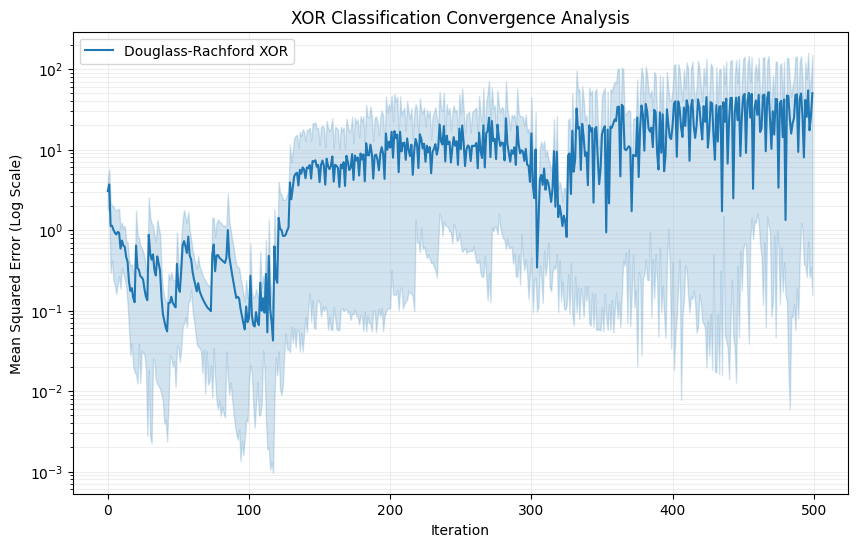

In [12]:
### Visualize Results
import numpy as np
df_results = pd.DataFrame(results.copy())
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_results, x="Iteration", y="Error", label='Douglass-Rachford XOR')

plt.yscale('log')
plt.title("XOR Classification Convergence Analysis")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()